In [1]:
!pip install scikit-learn

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
file_id = "1ra-rtRHvcOzBAfbsAxB9gJS_miJPez0o"
url = f"https://drive.google.com/uc?id={file_id}"
!wget -O playstore_reviews_shopee.csv {url}

--2025-03-16 10:53:39--  https://drive.google.com/uc?id=1ra-rtRHvcOzBAfbsAxB9gJS_miJPez0o
Resolving drive.google.com (drive.google.com)... 142.250.125.100, 142.250.125.139, 142.250.125.138, ...
Connecting to drive.google.com (drive.google.com)|142.250.125.100|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1ra-rtRHvcOzBAfbsAxB9gJS_miJPez0o [following]
--2025-03-16 10:53:39--  https://drive.usercontent.google.com/download?id=1ra-rtRHvcOzBAfbsAxB9gJS_miJPez0o
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 173.194.193.132, 2607:f8b0:4001:c0f::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|173.194.193.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1360142 (1.3M) [application/octet-stream]
Saving to: ‘playstore_reviews_shopee.csv’

playstore_reviews_s 100%[===================>]   1.30M  --.-KB/s    in 0.04s   

2025-03-16 

In [24]:
df = pd.read_csv('playstore_reviews_shopee.csv')
df.head()

,text,rating,clean_text,sentiment
0,toko online yang terpercaya dan terlengkap,5,toko online yang terpercaya dan terlengkap,Positif
1,Shopee okke,5,shopee okke,Positif
2,mantap,5,mantap,Positif
3,Mantap,5,mantap,Positif
4,hadehhh.... mau bayar pake shopeepay aja susah...,1,hadehhh mau bayar pake shopeepay aja susah ban...,Negatif


In [25]:
df = df.dropna(subset=['clean_text'])

In [26]:
X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [28]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

Akurasi Testing Set: 87.31%
              precision    recall  f1-score   support

     Negatif       0.74      0.70      0.72       386
      Netral       0.00      0.00      0.00        82
     Positif       0.90      0.96      0.93      1510

    accuracy                           0.87      1978
   macro avg       0.55      0.56      0.55      1978
weighted avg       0.83      0.87      0.85      1978



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


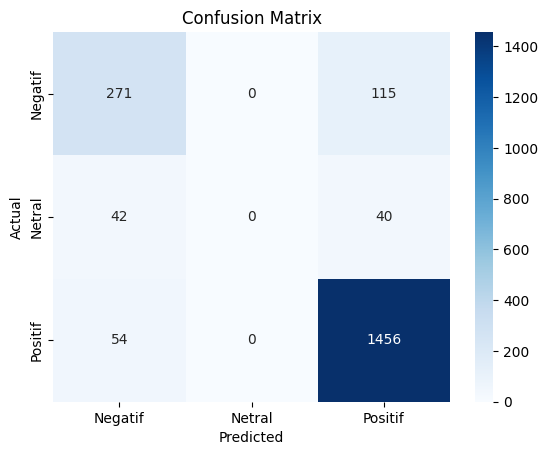

In [31]:
y_pred = model.predict(X_test_tfidf)

acc = accuracy_score(y_test, y_pred)
print(f"Akurasi Testing Set: {acc*100:.2f}%")

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=['Negatif', 'Netral', 'Positif'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negatif', 'Netral', 'Positif'], yticklabels=['Negatif', 'Netral', 'Positif'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()